(6349, 37)
(79447, 37)
Split date: 2003-12-23 00:00:00
Train rows: (63304, 73)
Test rows: (16143, 73)
Numeric: ['horse_age', 'horse_rating', 'declared_weight', 'actual_weight', 'draw', 'trainer_id', 'jockey_id', 'surface', 'distance', 'prize', 'race_class']
Categorical: ['horse_country', 'horse_type', 'horse_gear', 'venue', 'config', 'going', 'horse_ratings']


/var/folders/3n/lq4ggz856sndt290gxy6nkq00000gn/T/ipykernel_17254/3908747741.py:81: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X_train.select_dtypes(include=["object"]).columns.tolist()


Log loss: 0.2659836813748931
Brier score: 0.0714859887957573
Total bets: 3097
Total profit: -933.6
ROI: -0.3015
Hit rate: 0.0284


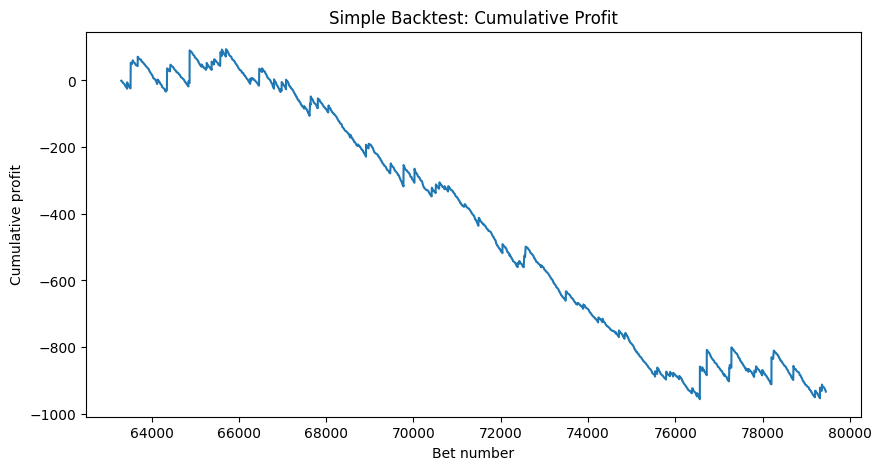

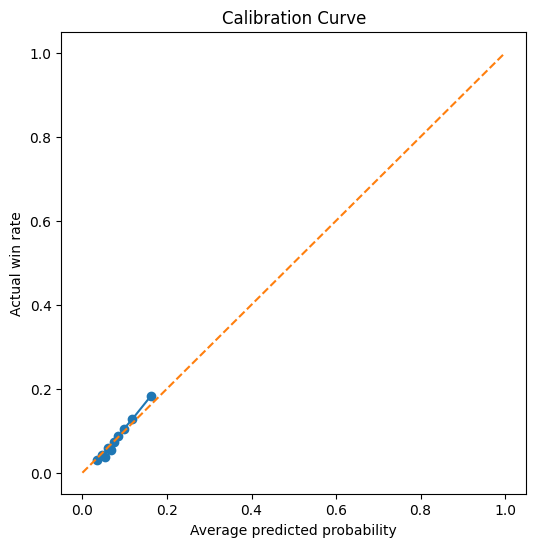

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import log_loss, brier_score_loss
from xgboost import XGBClassifier

races = pd.read_csv("../data/races.csv")
runs = pd.read_csv("../data/runs.csv")

print(races.shape)
print(runs.shape)

races.head()

df = runs.merge(races, on="race_id", how="left")

df.shape

df.columns.tolist()

df["won"] = (df["result"] == 1).astype(int)

df[["race_id", "horse_id", "result", "won"]].head()

df["date"] = pd.to_datetime(df["date"])

df = df.sort_values(["date", "race_id"]).reset_index(drop=True)

df[["race_id", "date", "horse_id", "result", "won"]].head()

features = [
    # Horse-level pre-race features
    "horse_age",
    "horse_country",
    "horse_type",
    "horse_rating",
    "horse_gear",
    "declared_weight",
    "actual_weight",
    "draw",
    "trainer_id",
    "jockey_id",

    # Race-level pre-race features
    "venue",
    "config",
    "surface",
    "distance",
    "going",
    "horse_ratings",
    "prize",
    "race_class",
]

features = [col for col in features if col in df.columns]

unique_dates = df["date"].sort_values().unique()

split_index = int(len(unique_dates) * 0.8)
split_date = unique_dates[split_index]

train = df[df["date"] < split_date].copy()
test = df[df["date"] >= split_date].copy()

print("Split date:", split_date)
print("Train rows:", train.shape)
print("Test rows:", test.shape)

X_train = train[features]
y_train = train["won"]

X_test = test[features]
y_test = test["won"]

numeric_features = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X_train.select_dtypes(include=["object"]).columns.tolist()

print("Numeric:", numeric_features)
print("Categorical:", categorical_features)

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

model = XGBClassifier(
    n_estimators=300,
    max_depth=3,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    random_state=42
)

pipe = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", model)
])

pipe.fit(X_train, y_train)

test["raw_model_prob"] = pipe.predict_proba(X_test)[:, 1]

test[["race_id", "horse_id", "raw_model_prob", "won"]].head()

test["model_prob"] = (
    test["raw_model_prob"] /
    test.groupby("race_id")["raw_model_prob"].transform("sum")
)

test.groupby("race_id")["model_prob"].sum().head()

print("Log loss:", log_loss(y_test, test["model_prob"]))
print("Brier score:", brier_score_loss(y_test, test["model_prob"]))

test = test[test["win_odds"].notna()].copy()
test = test[test["win_odds"] > 0].copy()

test["market_prob_raw"] = 1 / test["win_odds"]

test["market_prob"] = (
    test["market_prob_raw"] /
    test.groupby("race_id")["market_prob_raw"].transform("sum")
)

test["edge"] = test["model_prob"] - test["market_prob"]

test[[
    "race_id",
    "horse_id",
    "result",
    "won",
    "win_odds",
    "model_prob",
    "market_prob",
    "edge"
]].head(20)

bets = test[test["edge"] > 0.05].copy()

bets.shape

bets["profit"] = np.where(
    bets["won"] == 1,
    bets["win_odds"] - 1,
    -1
)

total_bets = len(bets)
total_profit = bets["profit"].sum()
roi = total_profit / total_bets if total_bets > 0 else 0
hit_rate = bets["won"].mean() if total_bets > 0 else 0

print("Total bets:", total_bets)
print("Total profit:", round(total_profit, 2))
print("ROI:", round(roi, 4))
print("Hit rate:", round(hit_rate, 4))

bets = bets.sort_values(["date", "race_id"]).copy()
bets["cumulative_profit"] = bets["profit"].cumsum()

plt.figure(figsize=(10, 5))
plt.plot(bets["cumulative_profit"])
plt.xlabel("Bet number")
plt.ylabel("Cumulative profit")
plt.title("Simple Backtest: Cumulative Profit")
plt.show()

test["prob_bucket"] = pd.qcut(test["model_prob"], 10, duplicates="drop")

calibration = test.groupby("prob_bucket", observed=True).agg(
    avg_predicted_prob=("model_prob", "mean"),
    actual_win_rate=("won", "mean"),
    count=("won", "size")
).reset_index()

calibration

plt.figure(figsize=(6, 6))
plt.plot(calibration["avg_predicted_prob"], calibration["actual_win_rate"], marker="o")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("Average predicted probability")
plt.ylabel("Actual win rate")
plt.title("Calibration Curve")
plt.show()